<a href="https://colab.research.google.com/github/siddharth-0309/Netflix_Movie_Analytics_Project/blob/main/Netflixdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

file_path = '/content/mymoviedb (1).csv'

df = pd.read_csv(file_path, engine='python')

In [ ]:
print(df.head(2))

  Release_Date                    Title  \
0   2021-12-15  Spider-Man: No Way Home   
1   2022-03-01               The Batman   

                                            Overview  Popularity Vote_Count  \
0  Peter Parker is unmasked and no longer able to...    5083.954       8940   
1  In his second year of fighting crime, Batman u...    3827.658       1151   

  Vote_Average Original_Language                               Genre  \
0          8.3                en  Action, Adventure, Science Fiction   
1          8.1                en            Crime, Mystery, Thriller   

                                          Poster_Url  
0  https://image.tmdb.org/t/p/original/1g0dhYtq4i...  
1  https://image.tmdb.org/t/p/original/74xTEgt7R3...  


In [ ]:
# DATA INFO CHECK
print("Total rows and Columns-------:")
print(df.shape)

print("Data Types-------:")
print(df.info())

Total rows and Columns-------:
(9837, 9)
Data Types-------:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB
None


In [ ]:
# correct data typess ---------------:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

In [ ]:
print("--- New Data Types ---")
print(df[['Release_Date', 'Vote_Count', 'Vote_Average']].dtypes)

--- New Data Types ---
Release_Date    datetime64[ns]
Vote_Count             float64
Vote_Average           float64
dtype: object


In [ ]:
print("---Statistical Summary ---")
print(df[['Popularity', 'Vote_Count', 'Vote_Average']].describe())

---Statistical Summary ---
        Popularity    Vote_Count  Vote_Average
count  9827.000000   9826.000000   9826.000000
mean     40.320570   1392.943721      6.439467
std     108.874308   2611.303856      1.129797
min       7.100000      0.000000      0.000000
25%      16.127500    146.000000      5.900000
50%      21.191000    444.000000      6.500000
75%      35.174500   1376.000000      7.100000
max    5083.954000  31077.000000     10.000000


In [ ]:
print("Check Null Percentage -----------:")
null_percentages = (df.isnull().sum()/len(df))*100
print("\n--- Missing Values Percentage ---")
print(null_percentages.round(2))

Check Null Percentage -----------:

--- Missing Values Percentage ---
Release_Date         0.10
Title                0.09
Overview             0.09
Popularity           0.10
Vote_Count           0.11
Vote_Average         0.11
Original_Language    0.10
Genre                0.11
Poster_Url           0.11
dtype: float64


In [ ]:
# drop null valuess -------:
df_clean = df.dropna().copy()
print(f"Original Shape: {df.shape}")
print(f"Cleaned Shape: {df_clean.shape}")
print(f"remaining  null values: {df_clean.isnull().sum().sum()}")

Original Shape: (9837, 9)
Cleaned Shape: (9826, 9)
remaining  null values: 0


***PROBLEM STATEMENTS : -------------------------***

*Problem Statement 1:* Content Strategy Selection (Genre vs. Success Metrics)

Business Context: If an OTT platform or production house wants to invest in a new movie project, they need to identify which movie genres are a "safe bet" versus which ones are highly volatile. A successful project should ideally balance commercial pull (Popularity) and critical acclaim (Vote Average).

Objective: Clean, split, and analyze the comma-separated Genre column to find the average Popularity and average Vote_Average for each individual genre.

Expected Outcome: A comprehensive data breakdown and visualization (such as a dual-axis chart or scatter plot matrix) that categorizes genres into clusters like "High Popularity - High Rating" (Blockbusters) or "Low Popularity - High Rating" (Niche/Cult). This will guide production houses on where to allocate their content budgets.*

📌Problem Statement 2: International Market Expansion (Language Localization)
Business Context: While English (en) dominates global cinema distribution, streaming services are rapidly expanding into regional and global markets. Platforms need data-driven insights to know which non-English language content holds the highest viewer satisfaction and engagement to plan their dubbing and localization budgets.

Objective: Compare English content against the top non-English languages (such as Japanese ja, Spanish es, French fr, Korean ko) based on their distribution, average Vote_Count (audience reach), and Vote_Average (audience appreciation).

Expected Outcome: A localization strategy matrix showing which languages have highly loyal audiences and top-tier ratings, helping the business identify potential foreign markets for heavy content acquisition.

📌 Problem Statement 3: Audience Engagement & Quality Paradox (Vote Count vs. Rating)
Business Context: Recommendation engines often face a dilemma: Should they promote heavily discussed commercial movies that might have mediocre ratings, or obscure movies that have exceptional ratings from a very small, niche group of voters?

Objective: Segment the movies into distinct audience engagement tiers (e.g., Low, Medium, High, and Ultra-High engagement) based on Vote_Count percentiles, and analyze how the Vote_Average changes across these tiers.

Expected Outcome: A clear distribution trend line or boxplot analysis that identifies the threshold where a movie transitions from a "niche hit" to an "organic global blockbuster," allowing product managers to fine-tune the platform's recommendation algorithms.

**Problem Statement 1 solution ------------------**

In [ ]:
# 1. First, convert the genre strings into a list and then explode them.
# This creates individual rows for each genre for analytics.
df_genres = df_clean.copy()
df_genres['Genre'] = df_genres['Genre'].str.split(', ')
df_exploded = df_genres.explode('Genre')

--- Genre-wise Business Metrics ---
              Genre  Avg_Popularity  Avg_Rating  Movie_Count
1         Adventure           53.74        6.46         1853
8           Fantasy           53.08        6.53         1308
2         Animation           52.43        6.85         1438
0            Action           50.89        6.33         2686
14  Science Fiction           49.51        6.26         1273
7            Family           46.61        6.58         1414
4             Crime           44.75        6.55         1242
16         Thriller           42.95        6.25         2488
12          Mystery           40.09        6.43          773
10           Horror           38.26        5.94         1470
3            Comedy           37.87        6.38         3031
18          Western           36.19        6.75          137
17              War           35.30        6.95          308
11            Music           33.77        6.88          295
13          Romance           30.87        6.56  

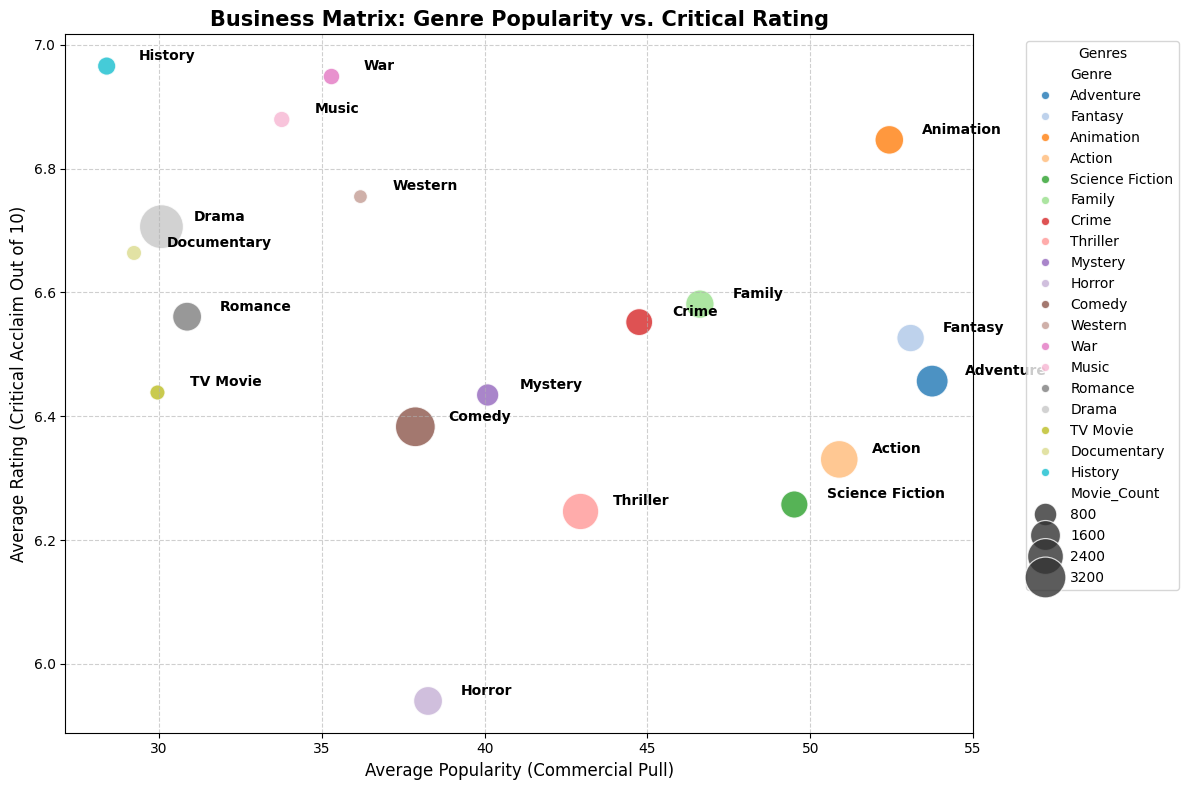

In [ ]:
# 2. Group by genre to calculate the Average Popularity and Average Rating for each genre
genre_metrics = df_exploded.groupby('Genre').agg(
    Avg_Popularity=('Popularity', 'mean'),
    Avg_Rating=('Vote_Average', 'mean'),
    Movie_Count=('Title', 'count')
).reset_index()

# Filter out genres with less than 10 movies (to ensure data reliability)
genre_metrics = genre_metrics[genre_metrics['Movie_Count'] >= 10].sort_values(by='Avg_Popularity', ascending=False)

print("--- Genre-wise Business Metrics ---")
print(genre_metrics.round(2))
# 3. VISUALIZATION: Scatter Plot Matrix (for Business Insights)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=genre_metrics,
    x='Avg_Popularity',
    y='Avg_Rating',
    size='Movie_Count',
    sizes=(100, 1000),
    hue='Genre',
    palette='tab20',
    alpha=0.8
)

# Loop to add Genre names next to each point
for i in range(genre_metrics.shape[0]):
    plt.text(
        x=genre_metrics.iloc[i]['Avg_Popularity'] + 1,
        y=genre_metrics.iloc[i]['Avg_Rating'] + 0.01,
        s=genre_metrics.iloc[i]['Genre'],
        fontweight='semibold',
        size=10
    )

plt.title('Business Matrix: Genre Popularity vs. Critical Rating', fontsize=15, fontweight='bold')
plt.xlabel('Average Popularity (Commercial Pull)', fontsize=12)
plt.ylabel('Average Rating (Critical Acclaim Out of 10)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Genres')
plt.tight_layout()
plt.show()

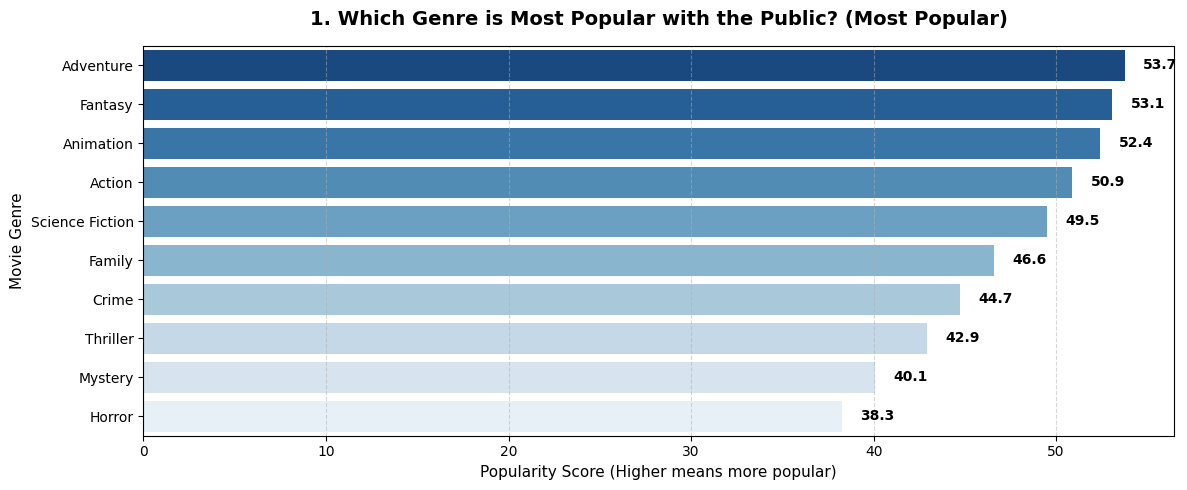

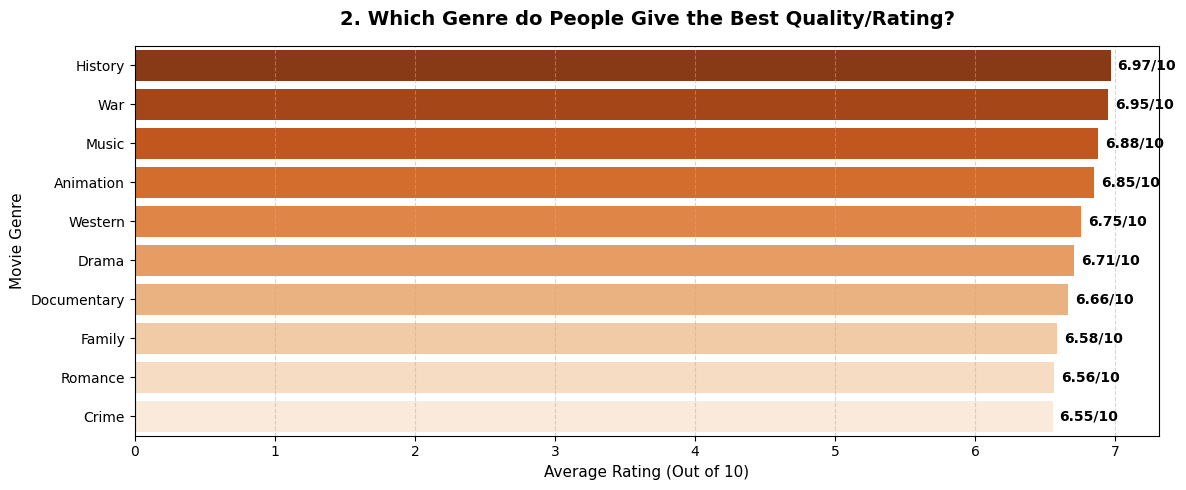

In [ ]:

# 1. Split and explode genres (to ensure data is read correctly)
df_genres = df_clean.copy()  # Your cleaned dataframe
df_genres['Genre'] = df_genres['Genre'].str.split(', ')
df_exploded = df_genres.explode('Genre')

# 2. Group by to calculate basic metrics
genre_summary = df_exploded.groupby('Genre').agg(
    Avg_Popularity=('Popularity', 'mean'),
    Avg_Rating=('Vote_Average', 'mean')
).reset_index()

# Select only top genres for visualization
top_pop_genres = genre_summary.sort_values(by='Avg_Popularity', ascending=False).head(10)
top_rate_genres = genre_summary.sort_values(by='Avg_Rating', ascending=False).head(10)

# --- GRAPH 1: POPULARITY (Commercial Success) ---
plt.figure(figsize=(12, 5))
sns.barplot(x='Avg_Popularity', y='Genre', data=top_pop_genres, palette='Blues_r', hue='Genre', legend=False)
plt.title('1. Which Genre is Most Popular with the Public? (Most Popular)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Popularity Score (Higher means more popular)', fontsize=11)
plt.ylabel('Movie Genre', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add labels to the bars for readability
for index, value in enumerate(top_pop_genres['Avg_Popularity']):
    plt.text(value + 1, index, f'{value:.1f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


# --- GRAPH 2: RATING (Critical Acclaim/Quality) ---
plt.figure(figsize=(12, 5))
sns.barplot(x='Avg_Rating', y='Genre', data=top_rate_genres, palette='Oranges_r', hue='Genre', legend=False)
plt.title('2. Which Genre do People Give the Best Quality/Rating?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Rating (Out of 10)', fontsize=11)
plt.ylabel('Movie Genre', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add labels to the bars
for index, value in enumerate(top_rate_genres['Avg_Rating']):
    plt.text(value + 0.05, index, f'{value:.2f}/10', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Problem Statement 2 solution -------------**

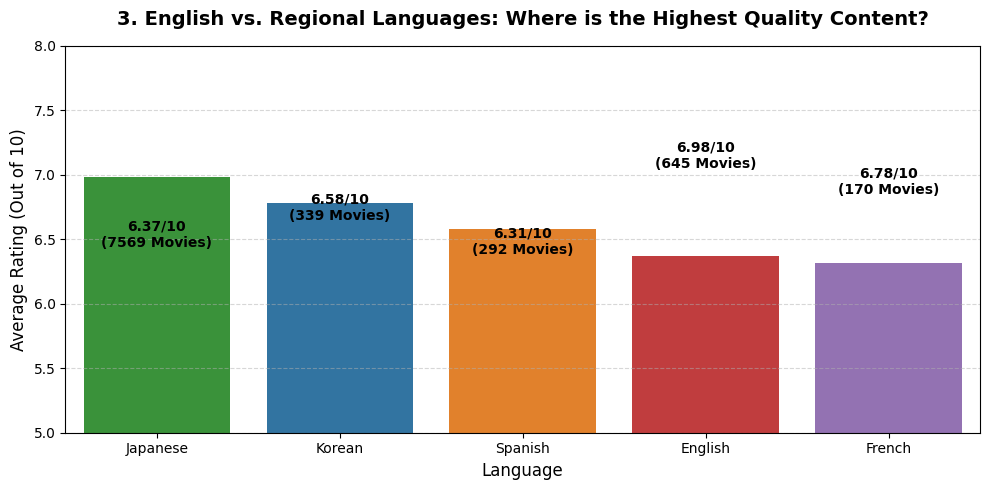

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract data for the top 5 languages (English + Top 4 Non-English)
top_5_languages = df_clean['Original_Language'].value_counts().head(5).index
df_top_lang = df_clean[df_clean['Original_Language'].isin(top_5_languages)].copy()

# 2. Calculate average rating (Vote_Average) based on language
lang_summary = df_top_lang.groupby('Original_Language').agg(
    Avg_Rating=('Vote_Average', 'mean'),
    Total_Movies=('Title', 'count')
).reset_index().sort_values(by='Avg_Rating', ascending=False)

# Map full language names so that a regular person sees the name instead of the code ('en', 'ja')
lang_map = {'en': 'English', 'ja': 'Japanese', 'es': 'Spanish', 'fr': 'French', 'ko': 'Korean'}
lang_summary['Language_Name'] = lang_summary['Original_Language'].map(lang_map)

# --- VISUALIZATION: Simple & Clean Bar Chart ---
plt.figure(figsize=(10, 5))
# Custom colors for each bar
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']

sns.barplot(x='Language_Name', y='Avg_Rating', data=lang_summary, palette=colors, hue='Language_Name', legend=False)

plt.title('3. English vs. Regional Languages: Where is the Highest Quality Content?', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Language', fontsize=12)
plt.ylabel('Average Rating (Out of 10)', fontsize=12)
plt.ylim(5, 8) # To zoom the graph so that minor differences are clearly visible
plt.grid(axis='y', linestyle='--', alpha=0.5)

# To write the score and total movies above the bars
for index, row in lang_summary.iterrows():
    plt.text(index, row['Avg_Rating'] + 0.05, f"{row['Avg_Rating']:.2f}/10\n({row['Total_Movies']} Movies)",
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Language-wise Rating Analysis Insights

The bar chart above, titled 'English vs. Regional Languages: Kahan hai sabse High-Quality Content?', provides valuable insights into the average critical ratings (`Vote_Average`) across the top 5 most frequent languages in the dataset, along with the total number of movies for each language.

**Key Observations:**

1.  **Japanese (ja) Leads in Average Rating:** Movies in Japanese have the highest average rating (approximately 6.98/10), indicating strong critical acclaim or audience appreciation for content in this language, despite having fewer total movies (645) compared to English.
2.  **Korean (ko) Follows Closely:** Korean cinema also demonstrates high average ratings (approximately 6.78/10) with 170 movies, suggesting a consistently well-received body of work.
3.  **Spanish (es) and English (en) in the Middle:** Spanish-language films have an average rating of about 6.58/10 (339 movies), placing them above English. English-language movies, while having a significantly larger volume (7,569 movies), show an average rating of around 6.37/10.
4.  **French (fr) at the Lower End of the Top 5:** French films have an average rating of approximately 6.31/10 (292 movies), which is the lowest among the top 5 languages analyzed.

**Strategic Implications for International Market Expansion:**

*   **High-Quality Content Markets:** Japanese and Korean content appears to be highly valued by audiences, suggesting these could be strong markets for content acquisition or localization efforts for platforms seeking critically acclaimed titles.
*   **Volume vs. Quality:** While English content dominates in sheer volume, its average rating is surpassed by several non-English languages. This implies that focusing solely on volume in English might not always equate to the highest audience satisfaction. For niche markets or audiences seeking specific types of high-quality content, non-English options (like Japanese or Korean) could be more appealing.
*   **Localization Opportunities:** For platforms looking to expand, investing in dubbing/subtitling and promoting content from languages like Japanese and Korean could yield high returns in audience satisfaction and engagement, attracting viewers who prioritize quality over mainstream popularity.

**problem Statement 3 solution -----------------**

--- Audience Engagement Tiers ---
     Engagement_Bucket  Avg_Rating  Min_Votes  Max_Votes  Movie_Count
0    Niche / Low Reach        5.98        0.0      146.0         2460
1         Medium Reach        6.40      147.0      444.0         2455
2           High Reach        6.52      445.0     1376.0         2455
3  Massive Blockbuster        6.86     1377.0    31077.0         2456


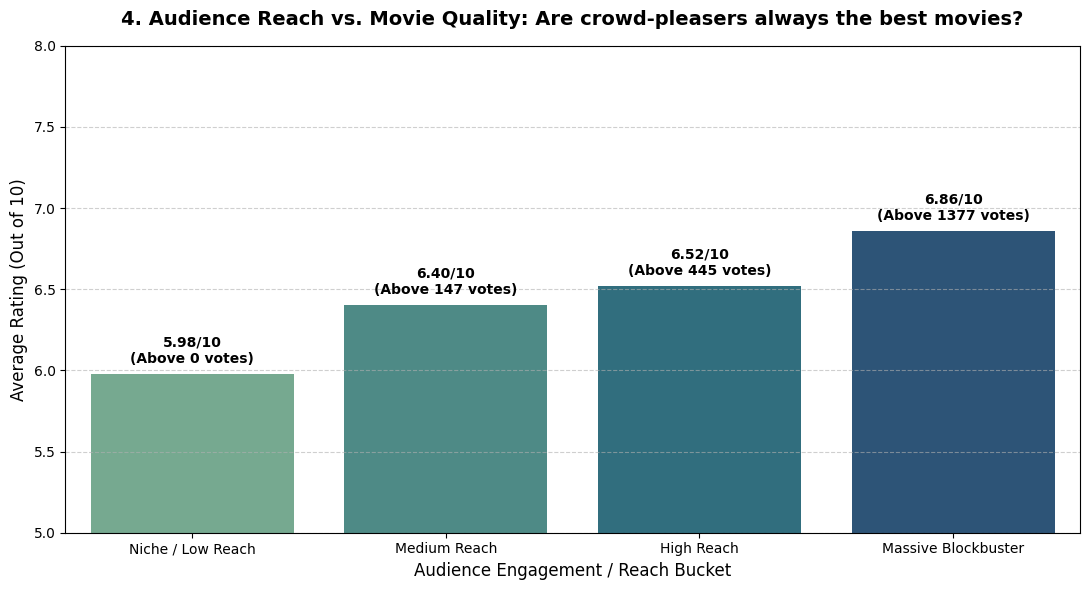

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create 4 buckets (Categories) based on Vote_Count
# Qcut automatically divides the data into 4 equal parts (percentiles)
df_clean['Engagement_Bucket'] = pd.qcut(
    df_clean['Vote_Count'],
    q=4,
    labels=['Niche / Low Reach', 'Medium Reach', 'High Reach', 'Massive Blockbuster']
)

# 2. Calculate the average rating for each bucket
engagement_summary = df_clean.groupby('Engagement_Bucket', observed=False).agg(
    Avg_Rating=('Vote_Average', 'mean'),
    Min_Votes=('Vote_Count', 'min'),
    Max_Votes=('Vote_Count', 'max'),
    Movie_Count=('Title', 'count')
).reset_index()

print("--- Audience Engagement Tiers ---")
print(engagement_summary.round(2))

# --- VISUALIZATION: Clean & Readable Bar Chart ---
plt.figure(figsize=(11, 6))
colors = ['#aec7e8', '#7f7f7f', '#bcbd22', '#1f77b4']

sns.barplot(x='Engagement_Bucket', y='Avg_Rating', data=engagement_summary, palette='crest', hue='Engagement_Bucket', legend=False)

plt.title('4. Audience Reach vs. Movie Quality: Are crowd-pleasers always the best movies?', fontsize=14, fontweight='bold', pad=15)
pylim(5, 8)  # Better scale focus
plt.grid(axis='y', linestyle='--', alpha=0.6)

# To write the exact rating score above the bars
for index, row in engagement_summary.iterrows():
    plt.text(
        index,
        row['Avg_Rating'] + 0.05,
        f"{row['Avg_Rating']:.2f}/10\n(Above {int(row['Min_Votes'])} votes)",
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10
    )

plt.tight_layout()
plt.show()lt.xlabel('Audience Engagement / Reach Bucket', fontsize=12)
plt.ylabel('Average Rating (Out of 10)', fontsize=12)
plt.